In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.widgets import Slider, Button
import pandas as pd
from scipy.interpolate import make_interp_spline

# Part 1: Self-diffusion (tracer diffusion) in a bar

## Part 1 (i): Derivation and analytical solutions

### Infinite bar: erf solution

Fick's second law with constant $D$:

$$\frac{\partial C}{\partial t}=D\frac{\partial^2C}{\partial x^2}$$

**IC:** $C(x,0)=C_1$ for $x<0$, $C_2$ for $x>0$ &nbsp;&nbsp; **BC:** $C(-\infty,t)=C_1$, $C(\infty,t)=C_2$

1. **Similarity variable.** With $\eta = x/(2\sqrt{Dt})$ the PDE becomes an ODE: $C'' + 2\eta\,C' = 0$.
2. **Integration.** $C' = A\,e^{-\eta^2}$, which gives $C = B + A'\,\mathrm{erf}(\eta)$.
3. **Constants.** $\mathrm{erf}(\pm\infty)=\pm1$ and the boundary conditions give $B=\tfrac{C_1+C_2}{2}$ and $A'=-\tfrac{C_1-C_2}{2}$.

$$C(x,t) = \frac{C_1 + C_2}{2} - \frac{C_1 - C_2}{2}\,\mathrm{erf}\!\left(\frac{x}{2\sqrt{Dt}}\right), \qquad
\frac{\partial C}{\partial x} = -\frac{C_1 - C_2}{2\sqrt{\pi D t}}\exp\!\left(-\frac{x^2}{4Dt}\right)$$

**The analytical solution (erf), briefly explained**

**The problem.** A bar of pure Cu (or Ni) where half of the atoms are labelled as tracer:
$C = 0$ for $x < 0$, $C = 1$ for $x > 0$. After 30 h at 1000 °C, self-diffusion has smeared out the
sharp boundary in the middle.

**The solution of Fick's 2nd law with these conditions:**

$$C(x,t) = \frac{C_1 + C_2}{2} - \frac{C_1 - C_2}{2}\,\mathrm{erf}\!\left(\frac{x}{2\sqrt{Dt}}\right)$$

- The first term is the mean value — where the profile ends up eventually.
- $\mathrm{erf}$ is an S-curve from $-1$ to $+1$ and gives the smooth transition.
- Everything depends on $x/(2\sqrt{Dt})$: **$\sqrt{Dt}$ is the length scale** for how far the
  diffusion has reached. A profile twice as wide requires four times as long.

**The gradient** is the derivative, a Gaussian bell curve with peak
$|C_1 - C_2|/(2\sqrt{\pi D t})$ at $x = 0$. The peak decreases with time, so the driving force for
further diffusion ($J = -D\,\partial C/\partial x$) decreases.

In [44]:
# Diffusion coefficient function, D(T)
def Diff_coeff(T, D0, Q):
    return D0*np.exp(-Q*1000/(R*T))

In [45]:
# Concentration profile function, C(x,t)
def Concentration_profile(x, t, D, C1, C2):
    return (C1+C2)/2 - (C1-C2)/2 * math.erf(x/(2*np.sqrt(D*t)))

In [46]:
# Concetraion gradients
def Concentration_gradient(x, t, D, C1, C2):
    return -(C1-C2)/(2*np.sqrt(np.pi*D*t)) * np.exp(-x**2/(4*D*t))

### Example: finite bar with fixed ends

Fick's second law on $[-L, L]$ with $L = 1$ mm:

$$\frac{\partial C}{\partial t}=D\frac{\partial^2C}{\partial x^2}$$

**BC:** $C(-L,t)=0$, $C(L,t)=1$ &nbsp;&nbsp; **IC:** $C(x,0)=0$ for $x<0$, $1$ for $x>0$

#### Procedure

1. **Steady state.** $C''=0$ gives $C_{ss}(x)=\tfrac12+\tfrac{x}{2L}$.
2. **Split off** with $u=C-C_{ss}$, so that $u(\pm L,t)=0$. Then $u_0(x)=\tfrac12\operatorname{sgn}(x)-\tfrac{x}{2L}$, which is odd about $x=0$.
3. **Separation of variables** on $u$: $T'=-\lambda DT$ and $X''=-\lambda X$. The boundary conditions give $k=m\pi/L$; the cosine modes vanish because $u_0$ is odd.
4. **Orthogonality** gives $a_m=\tfrac1L\int_{-L}^{L}u_0\sin\tfrac{m\pi x}{L}dx=+\tfrac{1}{m\pi}$.

#### Result

$$C(x,t)=\frac{1}{2}+\frac{x}{2L}+\frac{1}{\pi}\sum_{m=1}^{\infty}\frac{1}{m}\sin\!\left(\frac{m\pi x}{L}\right)\exp\!\left(-\frac{m^2\pi^2Dt}{L^2}\right)$$

The first term is the steady state (a straight ramp — not $\tfrac12$ everywhere, since the ends are held fixed), the second term is the deviation that dies out. Mode $m$ has lifetime $\tau_m = L^2/(m^2\pi^2 D)$.

In [47]:
# Analytical solution, finite bar with fixed ends

def analytical_solution(x, t, T, M=500):
    # Steady state: straight ramp from C=0 at x=-L to C=1 at x=+L
    D = Diff_coeff(T, D0_Cu, Q_Cu)  # ~1.9e-13 m^2/s
    C = 0.5 + x / (2 * L)
    # Adding the Fourier modes that die out with time
    for m in range(1, M + 1):
        # each mode: amplitude +1/(m*pi), shape factor sin(m*pi*x/L), damping exp(-m^2*pi^2*D*t/L^2)
        C += (1 / (m * np.pi)) * np.sin(m * np.pi * x / L) * np.exp(-(m * np.pi / L) ** 2 * D * t)
    return C

## Part 1 (ii): Isotherm annealing: Analytical solution

Result: plot of concentration vs distance and contration gradient vs distance 
Self diffusion of Ni* and Cu* tracer atoms in bars of Ni and Cu, respectively. 

In [48]:
# Problem parameters
T=1000+273.15 # K
t_tot=30*3600 # s
R=8.314 # J/mol*K
x = np.linspace(-1e-3, 1e-3, 101) # m, i.e. from -1 mm to 1 mm

# Material parameters (experimental values from table 2.2 in Porter et al. Phase Transformations in Metals and Alloys)
D0_Cu=31e-6 # m^2/s
D0_Ni=190e-6 # m^2/s
Q_Cu=200.3 # kJ/mol
Q_Ni=279.7 # kJ/mol

D_Cu=Diff_coeff(T, D0_Cu, Q_Cu)
D_Ni=Diff_coeff(T, D0_Ni, Q_Ni)

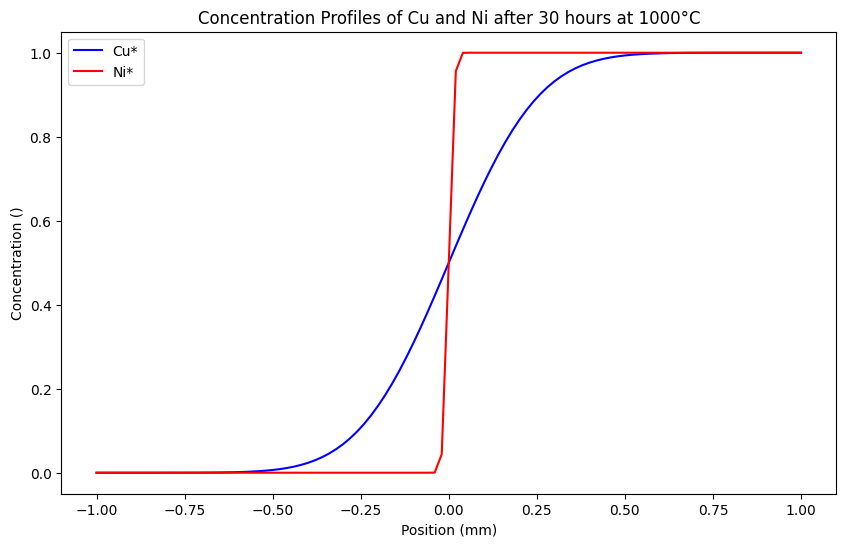

In [49]:
# Calculating concentration profiles for Cu and Ni, with inital condtion: 
# C(x,1)= 1 for x>0 and C(x,1)= 0 for x<0
C_Cu = []  
C_Ni = []

for xi in x:
    C_Cu.append(Concentration_profile(xi, t_tot, D_Cu, 0, 1))
    C_Ni.append(Concentration_profile(xi, t_tot, D_Ni, 0, 1))

# Plotting the concentration profiles
plt.figure(figsize=(10, 6))
plt.plot(x*1e3, C_Cu, label='Cu*', color='blue')
plt.plot(x*1e3, C_Ni, label='Ni*', color='red')
plt.title('Concentration Profiles of Cu and Ni after 30 hours at 1000°C')
plt.xlabel('Position (mm)')     
plt.ylabel('Concentration ()')
plt.legend()
plt.legend()

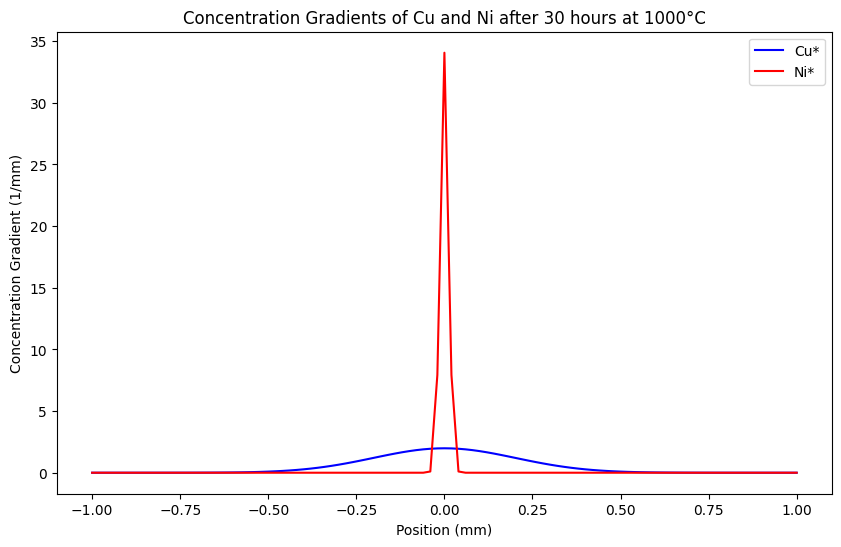

In [50]:
Cons_Cu_grad = []
Cons_Ni_grad = []

for xi in x:
    Cons_Cu_grad.append(Concentration_gradient(xi, t_tot, D_Cu, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm
    Cons_Ni_grad.append(Concentration_gradient(xi, t_tot, D_Ni, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm

plt.figure(figsize=(10, 6))
plt.plot(x*1e3, Cons_Cu_grad, label='Cu*', color='blue')
plt.plot(x*1e3, Cons_Ni_grad, label='Ni*', color='red')
plt.title('Concentration Gradients of Cu and Ni after 30 hours at 1000°C')
plt.xlabel('Position (mm)') 
plt.ylabel('Concentration Gradient (1/mm)')
plt.legend()        

### Finite bar with fixed ends

[]

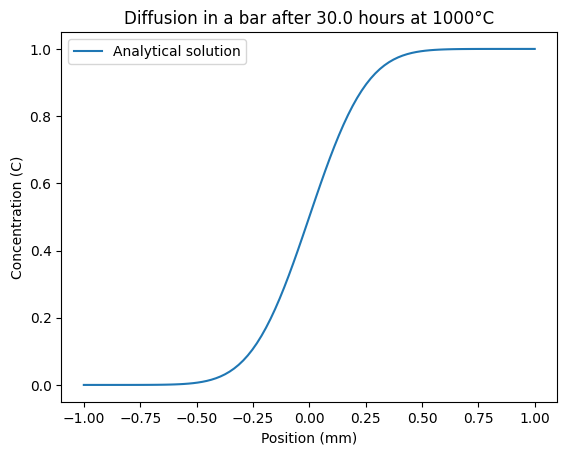

In [51]:
# ------------------- Parameters -------------------
L = 1e-3           # m, distance from the centre to the end of the bar
time = 30 * 3600   # s, 30 hours
T = 1000 + 273.15  # K, isothermal annealing at 1000 C
positions = np.linspace(-L, L, 100)  # 100 points from -L to L
# -------------------------------------------------

analytical_sol = analytical_solution(positions, time, T)
# multiplied by 1e3 to get mm on the x-axis (computed internally in metres since D is in m^2/s)
plt.plot(positions * 1e3, analytical_sol, label='Analytical solution')
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title(f'Diffusion in a bar after {time/3600} hours at 1000°C')
plt.legend()
plt.plot()

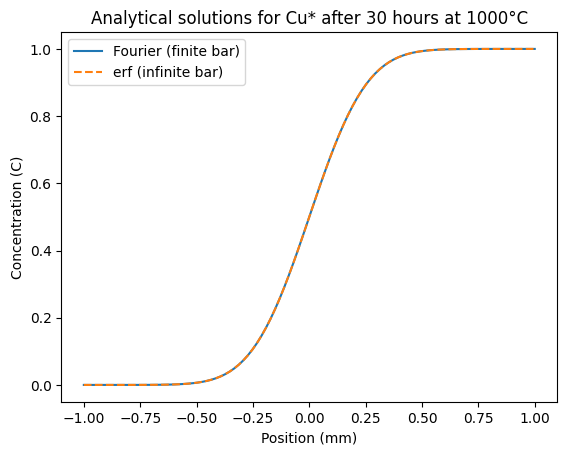

In [52]:
# Both analytical solutions in the same plot (Cu*, 30 h at 1000 °C). erf with C1=0, C2=1 for the same orientation
plt.figure()
plt.plot(positions * 1e3, analytical_sol, label='Fourier (finite bar)')
plt.plot(positions * 1e3, [Concentration_profile(xi, time, D_Cu, 0, 1) for xi in positions], '--', label='erf (infinite bar)')
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title('Analytical solutions for Cu* after 30 hours at 1000°C')
plt.legend()
plt.show()

## Part 1 (iii): Numerical solution with the finite difference method (FDM)

The bar is divided into grid points $x_j = j\,\Delta x$ and time into steps $t^n = n\,\Delta t$, and the derivatives in Fick's 2nd law are replaced by differences:

$$\frac{C_j^{n+1}-C_j^n}{\Delta t} = D\,\frac{C_{j+1}-2C_j+C_{j-1}}{(\Delta x)^2}$$

- **Explicit:** the right-hand side is evaluated at time $n$, so $C_j^{n+1}$ is computed directly. Stable only for $D\Delta t/(\Delta x)^2 \le \tfrac12$.
- **Implicit:** the right-hand side is evaluated at time $n+1$, which gives a tridiagonal system of equations per time step. Stable for all $\Delta t$.

### Numerical solution by finite difference method with explisit timesteps

Numerical solution to substitutional self-diffusion of tracer atoms in bar. I.e. Cu* in Cu and Ni* in Ni (diffusion couple) 

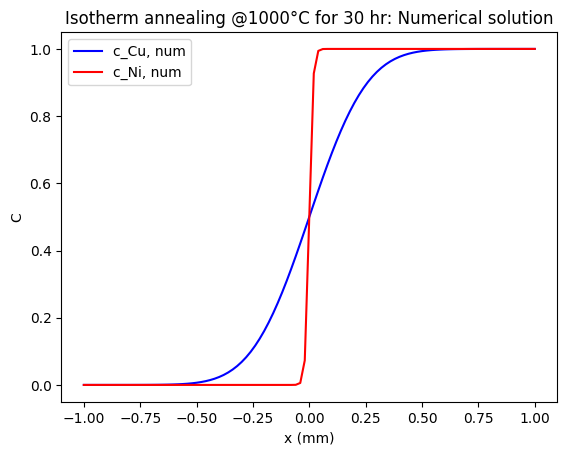

In [53]:
dx_mm = 0.02              # spatial step in mm
dx = dx_mm * 1e-3         # spatial step in m
dt=600 # timestep, seconds (should be within bounds of stability, i.e. dt < dx^2/(2*D))

N = int(t_tot/ dt)   # number of time steps
J = int(2/dx_mm)       # number of spatial steps

# Grid 
x = np.linspace(-1, 1, J+1) # mm
c = np.zeros(J+1)

# Initial condition 
# c(x,0) = 1 for x>0, 0 for x<0  
c[x > 0] = 1
c[x < 0] = 0
c[x == 0] = 0.5 # Condition at midpoint

def num_sol(D, c0, dt, dx, N, J):
    c = c0.copy()
    for n in range(N):
        c_new = c.copy()
        for j in range(1, J):
            c_new[j] = D*dt/dx**2 * (c[j+1] - 2*c[j] + c[j-1]) + c[j]
        c_new[0] = c0[0]   # Dirichlet: hold at initial boundary values
        c_new[J] = c0[J]
        c = c_new
    return c

c_Cu = num_sol(D_Cu, c, dt, dx, N, J)
c_Ni = num_sol(D_Ni, c, dt, dx, N, J)

plt.plot(x, c_Cu, label='c_Cu, num', color='blue')  
plt.plot(x, c_Ni, label='c_Ni, num', color='red')
plt.xlabel('x (mm)')
plt.ylabel('C')
plt.title('Isotherm annealing @1000°C for 30 hr: Numerical solution')
plt.legend()
plt.show()

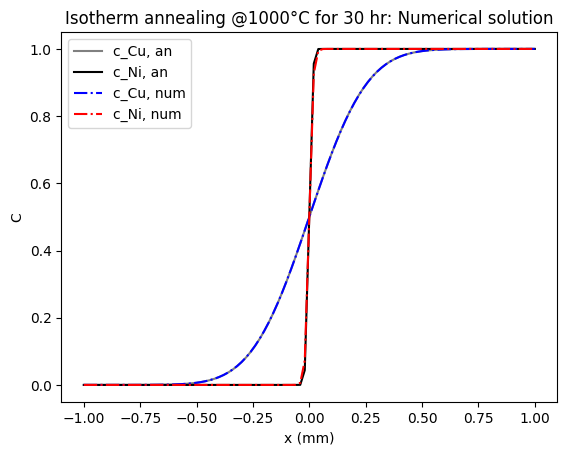

In [54]:
# Plot with analytical solution for comparison 
plt.plot(x, C_Cu, label='c_Cu, an',color='grey')
plt.plot(x, C_Ni, label='c_Ni, an', color='black')
plt.plot(x, c_Cu, label='c_Cu, num',linestyle='dashdot', color='blue')  
plt.plot(x, c_Ni, label='c_Ni, num',linestyle='dashdot', color='red')
plt.xlabel('x (mm)')
plt.ylabel('C')
plt.title('Isotherm annealing @1000°C for 30 hr: Numerical solution')
plt.legend()
plt.show()

### Explicit FDM with fluxes between the nodes (also accepts a vector of $D$)

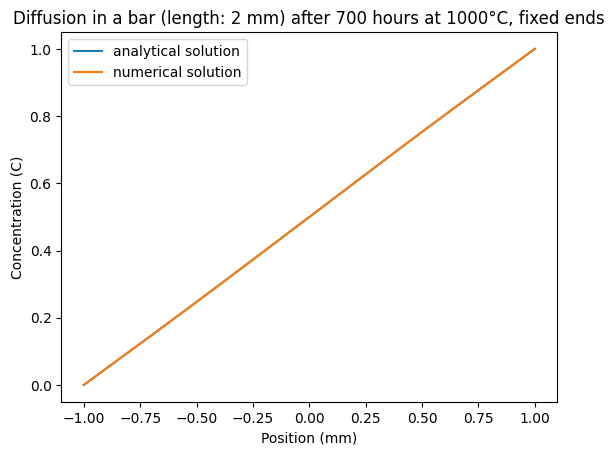

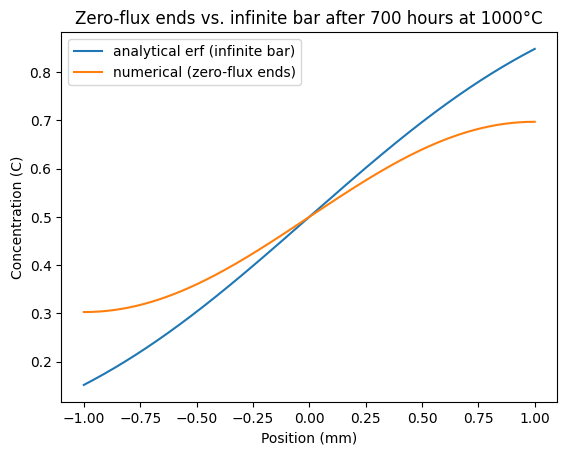

In [55]:
# Solution with the finite difference method, constant diffusion coefficient D and temperature T

#------------------------------------------------------------------------
#---------------------- Vurderer å fjerne hele greia --------------------
#------------------------------------------------------------------------

def central_diff(C, D, dx, D_list = None):
    if D_list is not None:
        # D midel between gridpoints:  D_{j+1/2} = (D_j + D_{j+1}) / 2
        D_face = 0.5 * (D_list[:-1] + D_list[1:])
        # Fick's 1st law on the faces:  J_{j+1/2} = -D_{j+1/2} * (C_{j+1} - C_j) / dx
        J = -D_face * (C[1:] - C[:-1]) / dx        # C[1:] = C_{j+1},  C[:-1] = C_j
    else:
        J = -D * (C[1:] - C[:-1]) / dx

    # dC_j/dt = -(J_{j+1/2} - J_{j-1/2}) / dx
    dCdt = np.zeros_like(C)
    dCdt[1:-1] = -(J[1:] - J[:-1]) / dx           # J[1:] = J_{j+1/2},  J[:-1] = J_{j-1/2}
    return dCdt, J

def iteration_1(C, D, dx, t_end, alpha=0.4):
    # dt is computed from stability: alpha = D*dt/dx^2 <= 0.5
    dt = alpha * dx**2 / D
    t = 0
    C = np.array(C, dtype=float)
    history = [C.copy()]
    while t < t_end:
        dcdt, J = central_diff(C, D, dx)
        C = C + dt * dcdt
        history.append(C.copy())
        t += dt
    return history

def iteration_2(C, D, dx, t_end, alpha=0.4):
    # dt is computed from stability: alpha = D*dt/dx^2 <= 0.5
    dt = alpha * dx**2 / D
    t = 0
    C = np.array(C, dtype=float)
    history = [C.copy()]
    while t < t_end:
        dcdt, J = central_diff(C, D, dx)
        C = C + dt * dcdt
        C[0]=C[1]; C[-1]=C[-2] # Different boundary condition, not fixed ends
        history.append(C.copy())
        t += dt
    return history

#----------- Parameters -----------------
grid_points = 300 # number of points
t_end = 3600 * 700 # s (700 hours)
T = 1000 + 273 # K
L = 1e-3 # m, distance from the centre to the ends of the bar

# C_grid
concentrations = np.zeros(grid_points)
concentrations[grid_points//2:] = 1.0

# positions
dx = 2*L / (grid_points - 1)
positions = np.linspace(-L,L,grid_points)
positions_fine = np.linspace(-L,L,1000)
D = Diff_coeff(T, D0_Cu, Q_Cu)

# ------------- Fixed concentration at the ends (C=0 at x=-L, C=1 at x=L) ----------------
analy = analytical_solution(positions_fine, t_end, T)
num = iteration_1(concentrations,D,dx,t_end,alpha=0.4)
plt.plot(positions_fine * 1e3,analy,label="analytical solution")
plt.plot(positions * 1e3,num[-1],label="numerical solution")   # num[-1] = last time step
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title(f'Diffusion in a bar (length: {2*L*1e3:.0f} mm) after {t_end/3600:.0f} hours at {T-273}°C, fixed ends')
plt.legend()
plt.plot()

# -------------- Fixed amount in the whole bar -------------------------------
# C1=0, C2=1 gives the same orientation as here: C=0 for x<0, C=1 for x>0
analy_erf = [Concentration_profile(xi, t_end, D, 0, 1) for xi in positions_fine]
num_2 = iteration_2(concentrations, D, dx, t_end, alpha=0.4)   # zero flux: C[0]=C[1], C[-1]=C[-2]

plt.figure()
plt.plot(positions_fine * 1e3, analy_erf, label="analytical erf (infinite bar)")
plt.plot(positions * 1e3, num_2[-1], label="numerical (zero-flux ends)")
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title(f'Zero-flux ends vs. infinite bar after {t_end/3600:.0f} hours at {T-273}°C')
plt.legend()
plt.show()

### Implicit FDM scheme

In [56]:
#Defining variables to use later
x_min = -1e-3   # m
x_max = 1e-3    # m
x_steps = 10
t_max = 30 # Hours
t_max = t_max * 3600 # Convert to seconds
t_steps = 10

D = Diff_coeff(T, D0_Cu, Q_Cu)   # Cu*  in Cu
# D = Diff_coeff(T, D0_Ni, Q_Ni) # Ni*  in Ni
# D = 10**-5

In [57]:
def setup(x_min=x_min, x_max=x_max, x_steps=x_steps, t_max=t_max, t_steps=t_steps, D=D):
    x = np.linspace(x_min, x_max, x_steps)
    C_matrix = np.zeros((t_steps, x_steps))
    C_matrix[0, :] = np.heaviside(x, 0.5)   # Using heaviside function to set the first row to 1 for x >= 0 and 0 for x < 0
    dx = (x_max - x_min) / (x_steps - 1)
    dt = t_max / (t_steps - 1)
    r = [D * dt / dx**2]*t_steps
    return C_matrix, dx, dt, r, x

C_matrix, dx, dt, r, x = setup()

In the cell above, a grid of 0s is defined, with the initial condition, C = 1 for positive x and 0 for negative x, is put into the grid. Also, dx, dt and r is defined. The r is defined to make calculations easier, and is a constant for a set time and space step, as well as a constant diffusion coefficiant.

Solving for the next time step for any given space point gives the following:

$$-r\,C_{i-1}^{n+1} + (1+2r)\,C_i^{n+1} - r\,C_{i+1}^{n+1} = C_i^n$$





The cell below solves one step of the implicit system, using a linalg system of this form:


$$
\begin{pmatrix}
1+2r & -2r &  &  &  \\
-r & 1+2r & -r &  & \Large{0} \\
 & \ddots & \ddots & \ddots &  \\
\Large{0} &  & -r & 1+2r & -r \\
 &  &  & -2r & 1+2r
\end{pmatrix}
\begin{pmatrix}
C_0^{n+1} \\ C_1^{n+1} \\ \vdots \\ C_{N-1}^{n+1} \\ C_N^{n+1}
\end{pmatrix}
=
\begin{pmatrix}
C_0^{n} \\ C_1^{n} \\ \vdots \\ C_{N-1}^{n} \\ C_N^{n}
\end{pmatrix}
$$

Here, the 2r points are because of the mirroring of these end points. This is implemented manually in the code.

In [58]:
def implicit_system_one_step(C_matrix, r, step, s = np.zeros(t_steps)):
    C0 = C_matrix[step, :]                      # Takes the step-th row of the C_matrix and stores it in C0
    # print(C0)
    A = np.zeros((len(C0), len(C0)))            # Creates a square matrix of zeros with the same length as C0 to be filled in. This as most of the matrix is 0s anyway.

    for i in range(0, len(C0)):                 # See structure in the markdown cell above. We only fill in the diagonal and the two diagonals next to it. 
        A[i, i] = 2*r[i] + 1
        if i != 0:
            A[i, i-1] = -r[i]+s[i]
        if i != len(C0)-1:
            A[i, i+1] = -r[i] - s[i]
    A[0, 1] = -2*r[0]                              # Adding the end points to fulfill the boundry conditions.
    A[-1, -2] = -2*r[-1]
    np.set_printoptions(precision=3, suppress=True, linewidth=120)
    # print(A)
    C1 = np.linalg.solve(A, C0)                 # Could be replaced by scipy for increase speed.
    # print(C1)
    return C1

In [59]:
def main():
    for step in range(0, t_steps-1):
        C_matrix[step+1, :] = implicit_system_one_step(C_matrix, r, step)
    return C_matrix

C_matrix = main()

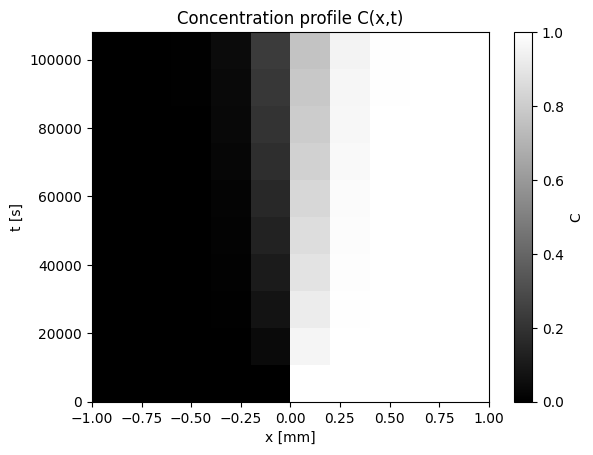

In [60]:
plt.imshow(C_matrix, aspect='auto', origin='lower', cmap='gray',
           extent=[x_min*1e3, x_max*1e3, 0, t_max])
plt.colorbar(label='C')
plt.xlabel('x [mm]')
plt.ylabel('t [s]')
plt.title('Concentration profile C(x,t)')
plt.show()

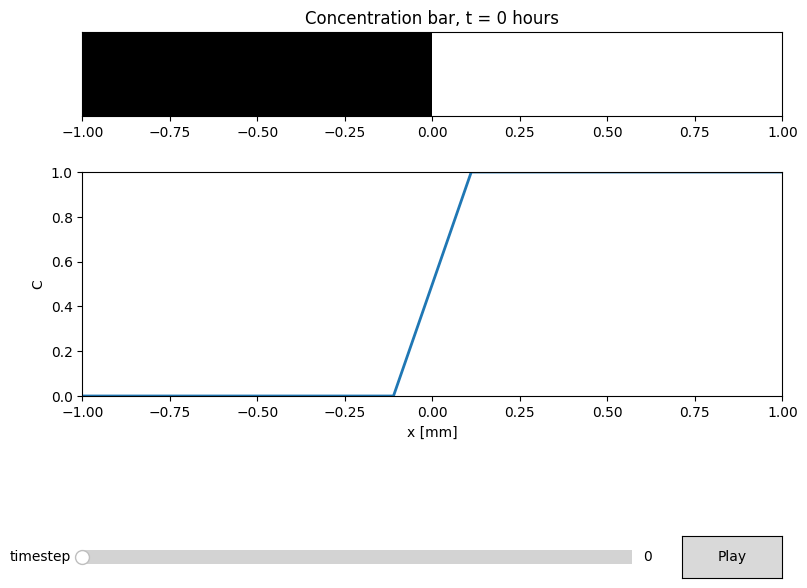

In [61]:
#  %matplotlib tk   


x = np.linspace(x_min, x_max, x_steps)

fig = plt.figure(figsize=(10, 7))

ax_bar   = fig.add_axes([0.15, 0.80, 0.7, 0.12])   # top: color strip
ax_line  = fig.add_axes([0.15, 0.40, 0.7, 0.32])   # middle: line plot
ax_slider = fig.add_axes([0.15, 0.15, 0.55, 0.04]) # slider
ax_button = fig.add_axes([0.75, 0.14, 0.10, 0.06]) # play/pause button

# top panel: solid concentration strip
img = ax_bar.imshow(C_matrix[[0]], cmap='gray', aspect='auto', vmin=0, vmax=1,
                     extent=[x_min*1e3, x_max*1e3, 0, 1])
ax_bar.set_yticks([])
ax_bar.set_title('Concentration bar, t = 0 hours')

# middle panel: line plot, updates together with the bar
line, = ax_line.plot(x*1e3, C_matrix[0], linewidth=2)
ax_line.set_xlim(x_min*1e3, x_max*1e3)
ax_line.set_ylim(0, 1)
ax_line.set_xlabel('x [mm]')
ax_line.set_ylabel('C')

slider = Slider(ax_slider, 'timestep', 0, t_steps - 1, valinit=0, valstep=1)
button = Button(ax_button, 'Play')

def update(val):
    n = int(slider.val)
    img.set_data(C_matrix[[n]])
    line.set_ydata(C_matrix[n])
    ax_bar.set_title(f'Concentration bar, t = {n*dt/3600:.2f} hours')
    fig.canvas.draw_idle()

slider.on_changed(update)

playing = [False]

def toggle_play(event):
    playing[0] = not playing[0]
    button.label.set_text('Pause' if playing[0] else 'Play')

button.on_clicked(toggle_play)

total_duration = 15
n_frames = 100          # fewer redraws = more likely to hit the real time budget
interval_ms = int(total_duration * 1000 / n_frames)   # ~150 ms per frame
step_size = max(1, t_steps // n_frames)

def advance():
    if playing[0]:
        n = (int(slider.val) + step_size) % t_steps
        slider.set_val(n)

timer = fig.canvas.new_timer(interval=interval_ms)   # use the variable, not a hardcoded 30
timer.add_callback(advance)
timer.start()

plt.show()

## Part 1 (iv): Non-isothermal annealing (continuous heating 10 °C/h, 700–1000 °C)

### Why $D$ is computed inside the loop

In isothermal annealing $T$ is constant, so $D$ can be computed once before the loop. Here
$T$ rises steadily from 700 to 1000 °C, and since $D = D_0 e^{-Q/RT}$, $D$ changes all the way.
It must therefore be updated every time step, using the temperature at that moment:

```python
D = Diff_coeff(T_start + t * DT_dt, D0_Cu, Q_Cu)
```

The time step has to be moved inside the loop for the same reason: the stability criterion
$dt = \alpha\,dx^2/D$ depends on $D$. When the bar is cold, long time steps are allowed, and
as it heats up the steps must get shorter for the solution to remain stable.

Number of iterations: 637


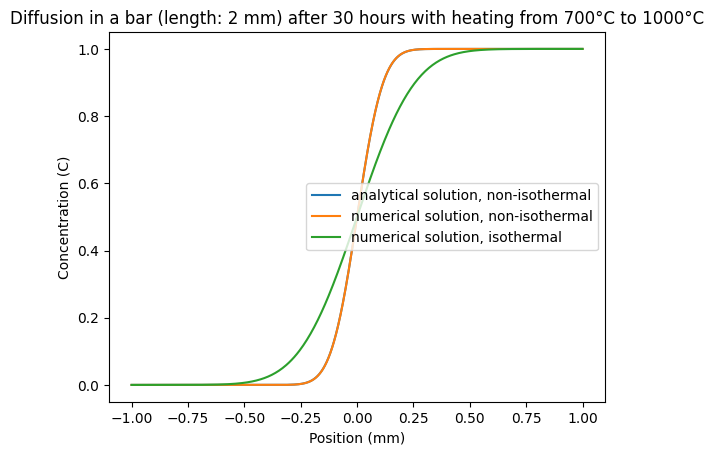

In [62]:
# Non-isothermal annealing

#------------------------------------------------------------------------

def central_diff(C, D, dx, D_list = None):
    if D_list is not None:
        # D midel between gridpoints:  D_{j+1/2} = (D_j + D_{j+1}) / 2
        D_face = 0.5 * (D_list[:-1] + D_list[1:])
        # Fick's 1st law on the faces:  J_{j+1/2} = -D_{j+1/2} * (C_{j+1} - C_j) / dx
        J = -D_face * (C[1:] - C[:-1]) / dx        # C[1:] = C_{j+1},  C[:-1] = C_j
    else:
        J = -D * (C[1:] - C[:-1]) / dx

    # dC_j/dt = -(J_{j+1/2} - J_{j-1/2}) / dx
    dCdt = np.zeros_like(C)
    dCdt[1:-1] = -(J[1:] - J[:-1]) / dx           # J[1:] = J_{j+1/2},  J[:-1] = J_{j-1/2}
    return dCdt, J

def iteration_annealing(C,T_start,T_end,dx,t_end,alpha=0.4):
    t = 0
    DT_dt = (T_end - T_start) / t_end
    C = np.array(C, dtype=float)
    history = [C.copy()]
    iterations = 0
    while t < t_end:
        D = Diff_coeff(T_start + t * DT_dt, D0_Cu, Q_Cu)
        dt = alpha * dx**2 / D
        dcdt, J = central_diff(C, D, dx)
        C = C + dt * dcdt
        history.append(C.copy())
        t += dt
        iterations += 1
    print("Number of iterations:", iterations)
    return history
    

def accumulated_Dt(T_start, T_end, t_end, n=10000):
    t = np.linspace(0, t_end, n)
    T_of_t = T_start + (T_end - T_start) * t / t_end
    return np.trapezoid(Diff_coeff(T_of_t, D0_Cu, Q_Cu), t)

def analytical_annealing(x, Dt, M=500):
    C = 0.5 + x / (2 * L)
    for m in range(1, M + 1):
        C += (1/(m*np.pi)) * np.sin(m*np.pi*x/L) * np.exp(-(m*np.pi/L)**2 * Dt)
    return C

#------------ Parameters -----------------
grid_points = 500 # number of points
t_end = 3600 * 30 # s (30 hours)
T = 1000 + 273 # K
L = 1e-3 # m, distance from the centre to the ends of the bar
T_start = 700 + 273 # K
T_final = 1000 + 273 # K

# C_grid
concentrations = np.zeros(grid_points)
concentrations[grid_points//2:] = 1.0

# positions
dx = 2*L / (grid_points - 1)   # same spacing as linspace gives
positions = np.linspace(-L,L,grid_points)
positions_fine = np.linspace(-L,L,1000)


Dt = accumulated_Dt(T_start, T_final, t_end)   # replaces D*t when D is not constant
analy = analytical_annealing(positions_fine, Dt)
num = iteration_annealing(concentrations,T_start,T_final,dx,t_end)
num_isothermal = iteration_1(concentrations,D,dx,t_end)

plt.plot(positions_fine * 1e3,analy,label="analytical solution, non-isothermal")
plt.plot(positions * 1e3,num[-1],label="numerical solution, non-isothermal")   # num[-1] = last time step
plt.plot(positions * 1e3,num_isothermal[-1],label="numerical solution, isothermal")   # num_isothermal[-1] = last time step
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title(f'Diffusion in a bar (length: {2*L*1e3:.0f} mm) after {t_end/3600:.0f} hours with heating from {T_start-273}°C to {T_final-273}°C')
plt.legend()
plt.show()

# Part 2: Interdiffusion in a Cu/Ni diffusion couple (Kirkendall effect)

## Part 2 (ii)

Here, we need the r as a function of local composition

$$ \frac{\partial C}{\partial t} = \tilde{D} \frac{\partial ^2 C}{\partial x^2} + \frac{\partial C}{\partial x} \frac{\partial \tilde{D}}{\partial x} $$

The first part corresponds to the same as before. The second part can be implemented in two separate schemes multiplied together. 

$$\frac{C_j^{n+1}-C_j^n}{\Delta t} = \tilde D_j^n\,\frac{C_{j+1}^{n+1}-2C_j^{n+1}+C_{j-1}^{n+1}}{(\Delta x)^2} + \left(\frac{\tilde D_{j+1}^n-\tilde D_{j-1}^n}{2\Delta x}\right)\left(\frac{C_{j+1}^{n+1}-C_{j-1}^{n+1}}{2\Delta x}\right)$$

Solved:
$$-\left(\frac{\tilde D_j^n\,\Delta t}{(\Delta x)^2} - \frac{\Delta t\,(\tilde D_{j+1}^n-\tilde D_{j-1}^n)}{4(\Delta x)^2}\right)C_{j-1}^{n+1} + \left(1+\frac{2\tilde D_j^n\,\Delta t}{(\Delta x)^2}\right)C_j^{n+1} - \left(\frac{\tilde D_j^n\,\Delta t}{(\Delta x)^2} + \frac{\Delta t\,(\tilde D_{j+1}^n-\tilde D_{j-1}^n)}{4(\Delta x)^2}\right)C_{j+1}^{n+1} = C_j^n$$

Defining variables to simplify the expression

$$r_j = \frac{\tilde D_j^n\,\Delta t}{(\Delta x)^2}$$

$$s_j = \frac{\Delta t\,(\tilde D_{j+1}^n-\tilde D_{j-1}^n)}{4(\Delta x)^2}$$

In [1]:
# Importing the dataset from the csv file and sorting them


values = pd.read_csv('D_tilda.csv', sep=';', header=None, decimal=',')
composition = values[0].values
lg_D_tilda  = values[1].values


# Interpolating between the values


lg_D_tilda_spline = make_interp_spline(composition, lg_D_tilda, k=3)

NameError: name 'pd' is not defined

In [64]:
# Taking in one step of concentrations and returning the effective diffusion coefficient D_tilda for each point in space.
def D_tilda(lg_D, C1_vector):
    return D1 * (1 - C1_vector) + D2 * C1_vector   # vectorised

def D_tilda2(C1_vector):
    return D * (1 - C1_vector) + D * C1_vector   # vectorised

# Defining the r for each D

def D_tilda_spline_vector(C1_vector):
    lg_D_tilda_vector = lg_D_tilda_spline(C1_vector)
    D_tilda_vector = 10**lg_D_tilda_vector
    return D_tilda_vector

def r_vector(D_tilda_vector, dt, dx):
    return D_tilda_vector * dt / dx**2   # vectorised, no loop needed

# Defining the s for each D

def s_vector(D_tilda_vector, dt, dx):
    s = np.zeros(len(D_tilda_vector))
    s[1:-1] = (D_tilda_vector[2:] - D_tilda_vector[:-2]) * dt / (4 * dx**2)
    return s

With the new quantities defined, the same implicit scheme can be used

In [65]:
C_matrix, dx, dt, r, x = setup()   # resets grid, dx and dt (dx is overwritten in Part 1 (iii)/(iv))

def main2():
    for step in range(0, t_steps-1):
        D_tilda_vector = D_tilda_spline_vector(C_matrix[step])
        r = r_vector(D_tilda_vector, dt, dx)
        s = s_vector(D_tilda_vector, dt, dx)
        C_matrix[step+1, :] = implicit_system_one_step(C_matrix, r, step, s)
    return C_matrix

print(main2())

NameError: name 'lg_D_tilda_spline' is not defined

# Extra: Monte Carlo simulation of vacancy diffusion

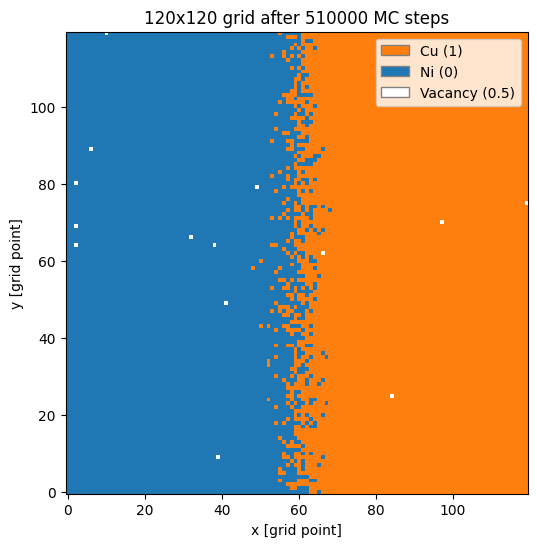

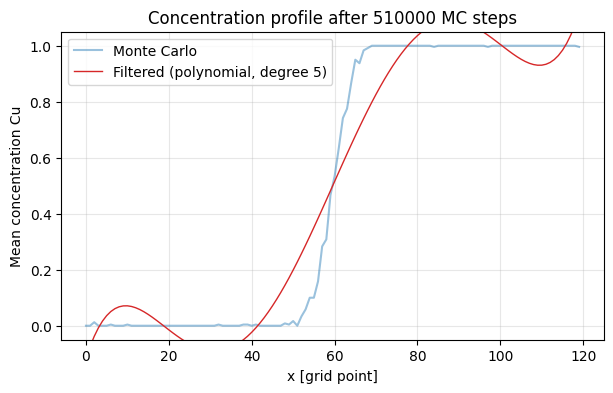

In [66]:
# Monte Carlo approach to find Fick's first law through vacancies

#----------- Parameters -----------------
x_grid = 120
y_grid = 120
MC_steps = 0.51e6
vacancy_volume = 0.1 # percent

MC_steps = int(MC_steps)
vacancy_volume = vacancy_volume/100

Grid = np.zeros((x_grid, y_grid))
Grid[len(Grid)//2:,:] = 1
n_vacancies = int(vacancy_volume * x_grid * y_grid)
for i in range(n_vacancies):
    x = np.random.randint(0, x_grid)
    y = np.random.randint(0, y_grid)
    Grid[x, y] = 0.5

# ------------------ Monte Carlo part -----------------------------
def Monte_carlo_diff(Grid, MC):
    vacancies = np.argwhere(Grid == 0.5)   # array with [x, y] for each vacancy
    # pre-generate some values for faster code
    choice = np.random.randint(0, len(vacancies), MC)
    dxs = np.random.choice([-1, 1], MC)
    dys = np.random.choice([-1, 1], MC)
    for i in range(MC):
        inx = choice[i]
        x, y = vacancies[inx]
        dx = dxs[i]
        dy = dys[i]
        if x + dx < 0 or x + dx >= x_grid:
            dx = 0
        if y + dy < 0 or y + dy >= y_grid:
            dy = 0
        neighbour = Grid[x + dx, y + dy]
        if neighbour != 0.5:                 # the neighbour is an atom (Cu or Ni), not another vacancy
            Grid[x, y] = neighbour           # the atom moves into where the vacancy was
            Grid[x + dx, y + dy] = 0.5       # the vacancy ends up where the atom was
            vacancies[inx] = [x + dx, y + dy]  # updates the position of the vacancy
    return Grid

Grid = Monte_carlo_diff(Grid, MC_steps)

# ---------------------- Plotting ----------------------
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

colors = ListedColormap(['tab:blue', 'white', 'tab:orange'])
norm = BoundaryNorm([-0.25, 0.25, 0.75, 1.25], colors.N)
plt.figure(figsize=(6, 6))
plt.imshow(Grid.T, cmap=colors, norm=norm, origin='lower', interpolation='nearest')
plt.xlabel('x [grid point]')
plt.ylabel('y [grid point]')
plt.title(f'{x_grid}x{y_grid} grid after {MC_steps} MC steps')
plt.legend(handles=[Patch(facecolor='tab:orange', edgecolor='grey', label='Cu (1)'),Patch(facecolor='tab:blue', edgecolor='grey', label='Ni (0)'),Patch(facecolor='white', edgecolor='grey', label='Vacancy (0.5)')],loc='upper right')
plt.show()

#------------- Mean concentration per x position --------
# the mean over all y for each x, i.e. np.mean(Grid[i,:]) for i = 0..x_grid-1
mean_profile = Grid.mean(axis=1)

# Filtering: least-squares fit of one polynomial over the whole profile.
degree = 5
mean_smoothed = np.polyval(np.polyfit(np.arange(x_grid), mean_profile, degree), np.arange(x_grid))

plt.figure(figsize=(7, 4))
plt.plot(np.arange(x_grid), mean_profile, '-', ms=3, alpha=0.45, label='Monte Carlo')
plt.plot(np.arange(x_grid), mean_smoothed, '-', lw=1, color='tab:red', label=f'Filtered (polynomial, degree {degree})')
plt.xlabel('x [grid point]')
plt.ylabel('Mean concentration Cu')
plt.title(f'Concentration profile after {MC_steps} MC steps')
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()